Synthetic data shapes:
t: (251,) U: (251, 1) X: (251, 14) Y: (251, 1)
Synthetic proxy ranges:
xp range: 0.0007458081100532032
xn range: 0.0007458081100207847
ceL range: 0.362176034404456
ceR range: 0.362176034404456


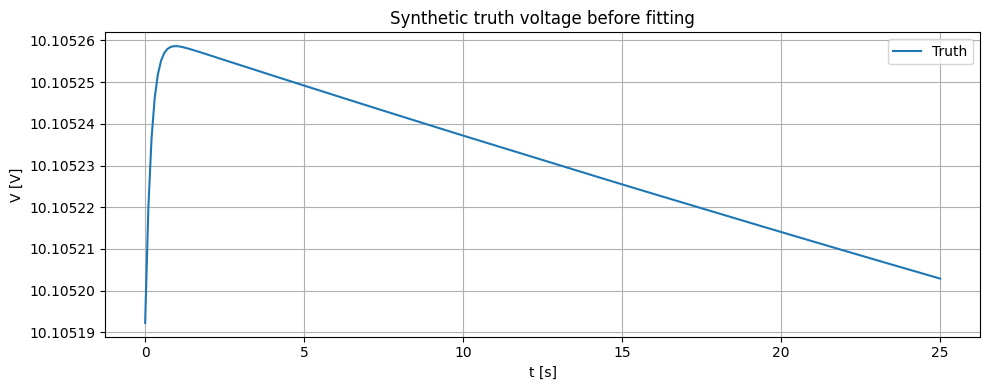

  0%|                        |

Solving NLP with Adam (10 optimization variables) ...


100%|████████████████████████|
    f =   0.000001, f* =  0.000001, |grad f| =  0.004069, iter = 2000
  0%|                        |

Solving NLP with Adam (11 optimization variables) ...


100%|████████████████████████|
    f =   0.000001, f* =  0.000001, |grad f| =  0.000000, iter = 1800
  0%|                        |

Solving NLP with Adam (21 optimization variables) ...


 97%|███████████████████████▎|

In [ ]:
# Cell 0 — Imports
from __future__ import annotations

import jax
jax.config.update("jax_enable_x64", True)

import numpy as np
from IPython.display import display

from battery_deg_spme.analysis.nonlinearity import (
    compare_surfaces_on_grid,
    evaluate_surface_on_grid,
)
from battery_deg_spme.analysis.summaries import (
    compare_truth_and_estimated_parameters,
    make_stage_summary_table,
)
from battery_deg_spme.config.settings import get_default_settings
from battery_deg_spme.fitting.stage2 import fit_stage2_for_cycle
from battery_deg_spme.fitting.stage3 import fit_stage3a_for_cycle, fit_stage3b_for_cycle
from battery_deg_spme.models.parameterization import thetaA_nom_from_cfg, thetaB_nom_from_cfg
from battery_deg_spme.models.spme_proxy import Config, IDX, build_proxy_signals
from battery_deg_spme.models.synthetic_truth import generate_discharge_data, truth_z_from_xn_xp
from battery_deg_spme.visualization.fit_plots import (
    plot_residuals,
    plot_stage_fit_comparison,
    plot_voltage,
)
from battery_deg_spme.visualization.nonlinearity_plots import (
    plot_heatmap,
    plot_nonlinearity_heatmap,
    plot_nonlinearity_surface,
    plot_residual_heatmap,
    plot_residual_surface_3d,
    plot_surface_3d,
    plot_surface_3d_compare,
    plot_surrogate_contours,
)


# Cell 1 — Helper for learned surface
def _build_learned_surface_fn(
    thetaZ_hat: np.ndarray,
    zhat_from_thetaZ,
    cfg,
    state_template: np.ndarray,
):
    thetaZ_hat = np.asarray(thetaZ_hat, dtype=np.float64).reshape(-1)
    state_template = np.asarray(state_template, dtype=np.float64).reshape(-1)

    def learned_surface_fn(xn: float, xp: float) -> float:
        x = state_template.copy()
        x[IDX["cn_surf"]] = float(xn) * float(cfg.csn_max)
        x[IDX["cp_surf"]] = float(xp) * float(cfg.csp_max)
        return float(zhat_from_thetaZ(x, thetaZ_hat))

    return learned_surface_fn


# Cell 2 — Settings
settings = get_default_settings()
cfg = Config()
cfg.N_series = 3
cfg.discharge_positive = True

# Synthetic-only overrides
settings.surrogate.poly_deg = 4
settings.surrogate.use_ln_feature = False

settings.optimization.use_lbfgs = False

settings.optimization.adam_epochs_stage2 = 2000
settings.optimization.adam_epochs_stage3a = 1800
settings.optimization.adam_epochs_stage3b = 2500

settings.optimization.adam_eta_stage2 = 1e-3
settings.optimization.adam_eta_stage3a = 5e-4
settings.optimization.adam_eta_stage3b = 1e-4

settings.solver.dt0_div = 50.0
settings.solver.solver_rtol = 1e-6
settings.solver.solver_atol = 1e-9
settings.solver.max_steps = 5_000_000


# Cell 3 — Generate synthetic truth data
t, U, X, Y, Y_full = generate_discharge_data(
    cfg=cfg,
    I_const=2.0,
    sim_t_end=25.0,
    sim_dt=0.1,
    theta_n0=0.8,
    theta_p0=0.4,
    ce0=0.0,
)

# Use the regular proxy path for synthetic too
proxy = build_proxy_signals(
    t_np=t,
    u_np=U,
    cfg=cfg,
    xn0=0.8,
    xp0=0.4,
    ce0_dev=0.0,
)

print("Synthetic data shapes:")
print("t:", t.shape, "U:", U.shape, "X:", X.shape, "Y:", Y.shape)
print("Synthetic proxy ranges:")
print("xp range:", proxy["xp_rng"])
print("xn range:", proxy["xn_rng"])
print("ceL range:", proxy["ceL_rng"])
print("ceR range:", proxy["ceR_rng"])


# Cell 4 — Plot the initial synthetic data that will be fit
plot_voltage(
    t,
    Y,
    title="Synthetic truth voltage before fitting",
    measured_label="Truth",
    show=True,
)


# Cell 5 — Stage 2 / 3a / 3b fits
stage2 = fit_stage2_for_cycle(
    t_np=t,
    u_np=U,
    y_np=Y,
    proxy=proxy,
    cfg=cfg,
    settings=settings,
)

stage3a = fit_stage3a_for_cycle(
    t_np=t,
    u_np=U,
    y_np=Y,
    proxy=proxy,
    stage2_result=stage2,
    cfg=cfg,
    settings=settings,
)

stage3b = fit_stage3b_for_cycle(
    t_np=t,
    u_np=U,
    y_np=Y,
    proxy=proxy,
    stage2_result=stage2,
    stage3a_result=stage3a,
    cfg=cfg,
    settings=settings,
)


# Cell 6 — Fit plots
plot_voltage(
    t,
    Y,
    stage2["yhat"],
    title="Synthetic truth vs Stage 2",
    measured_label="Truth",
    pred_label="Stage 2",
    show=True,
)

plot_voltage(
    t,
    Y,
    stage3a["yhat"],
    title="Synthetic truth vs Stage 3a",
    measured_label="Truth",
    pred_label="Stage 3a",
    show=True,
)

plot_voltage(
    t,
    Y,
    stage3b["yhat"],
    title="Synthetic truth vs Stage 3b",
    measured_label="Truth",
    pred_label="Stage 3b",
    show=True,
)

plot_residuals(
    t,
    Y,
    stage2["yhat"],
    title="Synthetic Stage 2 residuals",
    show=True,
)

plot_residuals(
    t,
    Y,
    stage3b["yhat"],
    title="Synthetic Stage 3b residuals",
    show=True,
)

plot_stage_fit_comparison(
    t,
    Y,
    {
        "Stage 2": stage2["yhat"],
        "Stage 3a": stage3a["yhat"],
        "Stage 3b": stage3b["yhat"],
    },
    title="Synthetic truth vs stage fits",
    show=True,
)


# Cell 7 — Stage summary table
stage_summary_df = make_stage_summary_table(
    {
        "stage2": stage2,
        "stage3a": stage3a,
        "stage3b": stage3b,
    }
)
display(stage_summary_df)

print("Synthetic Stage 2 RMSE:", stage2["metrics"]["rmse"])
print("Synthetic Stage 3a RMSE:", stage3a["metrics"]["rmse"])
print("Synthetic Stage 3b RMSE:", stage3b["metrics"]["rmse"])


# Cell 8 — Truth and learned surface functions
I_ref = float(U[0, 0])

def truth_surface_fn(xn: float, xp: float) -> float:
    return truth_z_from_xn_xp(
        cfg=cfg,
        xn=xn,
        xp=xp,
        I=I_ref,
        ceL=cfg.ce0,
        ceR=cfg.ce0,
    )

zhat_from_thetaZ = stage2["zhat_from_thetaZ"]

stage2_surface_fn = _build_learned_surface_fn(
    thetaZ_hat=stage2["thetaZ_hat"],
    zhat_from_thetaZ=zhat_from_thetaZ,
    cfg=cfg,
    state_template=np.asarray(X[0], dtype=np.float64),
)

stage3b_surface_fn = _build_learned_surface_fn(
    thetaZ_hat=stage3b["thetaZ_hat"],
    zhat_from_thetaZ=zhat_from_thetaZ,
    cfg=cfg,
    state_template=np.asarray(stage3b["xhat"][0], dtype=np.float64),
)


# Cell 9 — Truth nonlinearity visuals
truth_surface = evaluate_surface_on_grid(
    surface_fn=truth_surface_fn,
    n_per_axis=settings.surrogate.nonlinearity_grid_n,
    guard=settings.surrogate.nonlinearity_guard,
)

plot_nonlinearity_heatmap(
    truth_surface.XN,
    truth_surface.XP,
    truth_surface.Z,
    title="Truth nonlinearity heatmap",
    show=True,
)

plot_nonlinearity_surface(
    truth_surface.XN,
    truth_surface.XP,
    truth_surface.Z,
    title="Truth nonlinearity 3D surface",
    show=True,
)

plot_surrogate_contours(
    truth_surface.xn_grid,
    truth_surface.xp_grid,
    truth_surface.Z,
    title="Truth nonlinearity contours",
    show=True,
)


# Cell 10 — Truth vs Stage 2 surface comparison
stage2_comparison = compare_surfaces_on_grid(
    ref_surface_fn=truth_surface_fn,
    learned_surface_fn=stage2_surface_fn,
    n_per_axis=settings.surrogate.nonlinearity_grid_n,
    guard=settings.surrogate.nonlinearity_guard,
    title="Truth vs Stage 2 nonlinearity",
)

plot_surface_3d_compare(
    stage2_comparison.XN,
    stage2_comparison.XP,
    stage2_comparison.Z_ref,
    stage2_comparison.Z_hat,
    title="Truth vs Stage 2: 3D compare",
    show=True,
)

plot_heatmap(
    stage2_comparison.XN,
    stage2_comparison.XP,
    stage2_comparison.Z_ref,
    title="Truth heatmap",
    show=True,
)

plot_surface_3d(
    stage2_comparison.XN,
    stage2_comparison.XP,
    stage2_comparison.Z_hat,
    title="Stage 2 learned surface",
    show=True,
)

plot_residual_heatmap(
    stage2_comparison.XN,
    stage2_comparison.XP,
    stage2_comparison.residual,
    title="Truth vs Stage 2 residual heatmap",
    show=True,
)

plot_residual_surface_3d(
    stage2_comparison.XN,
    stage2_comparison.XP,
    stage2_comparison.residual,
    title="Truth vs Stage 2 residual 3D surface",
    show=True,
)


# Cell 11 — Truth vs Stage 3b surface comparison
stage3b_comparison = compare_surfaces_on_grid(
    ref_surface_fn=truth_surface_fn,
    learned_surface_fn=stage3b_surface_fn,
    n_per_axis=settings.surrogate.nonlinearity_grid_n,
    guard=settings.surrogate.nonlinearity_guard,
    title="Truth vs Stage 3b nonlinearity",
)

plot_surface_3d_compare(
    stage3b_comparison.XN,
    stage3b_comparison.XP,
    stage3b_comparison.Z_ref,
    stage3b_comparison.Z_hat,
    title="Truth vs Stage 3b: 3D compare",
    show=True,
)

plot_heatmap(
    stage3b_comparison.XN,
    stage3b_comparison.XP,
    stage3b_comparison.Z_hat,
    title="Stage 3b learned heatmap",
    show=True,
)

plot_residual_heatmap(
    stage3b_comparison.XN,
    stage3b_comparison.XP,
    stage3b_comparison.residual,
    title="Truth vs Stage 3b residual heatmap",
    show=True,
)

plot_residual_surface_3d(
    stage3b_comparison.XN,
    stage3b_comparison.XP,
    stage3b_comparison.residual,
    title="Truth vs Stage 3b residual 3D surface",
    show=True,
)


# Cell 12 — True vs estimated parameter table
theta_true = np.concatenate([thetaA_nom_from_cfg(cfg), thetaB_nom_from_cfg(cfg)])
theta_hat = np.concatenate([stage3b["thetaA_hat_stage3b"], stage3b["thetaB_hat_stage3b"]])

names = [
    "thetaA_1",
    "thetaA_2",
    "thetaA_3",
    "thetaA_4",
    "thetaA_5",
    "thetaA_6",
    "thetaA_7",
    "thetaB_8",
    "thetaB_9",
    "thetaB_10",
    "thetaB_11",
]

param_compare_df = compare_truth_and_estimated_parameters(
    theta_true=theta_true,
    theta_hat=theta_hat,
    names=names,
)
display(param_compare_df)